In [1]:
# --- Figure 3 notebook header ---
import sys, pickle
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt

here = Path.cwd()
for p in [here, *here.parents]:
    if (p / "utils.py").exists():
        sys.path.insert(0, str(p)); REPO = p; break
import utils
utils.frontiers_style()

cache = REPO / "cache"
with open(cache / "meta.pkl", "rb") as f:
    meta = pickle.load(f)
file_names   = meta["file_names"]
problem_type = meta["problem_type"]
scores       = meta["scores"]
with open(cache / "out_agg.pkl", "rb") as f:
    out_agg = pickle.load(f)

basic_info = utils.load_basic_info()
clf, reg = utils.split_problem_lists(file_names, basic_info)
print(f"loaded: {len(file_names)} tasks | {len(clf)} clf | {len(reg)} reg | out_agg for {len(out_agg)} tasks")

loaded: 31 tasks | 14 clf | 17 reg | out_agg for 31 tasks


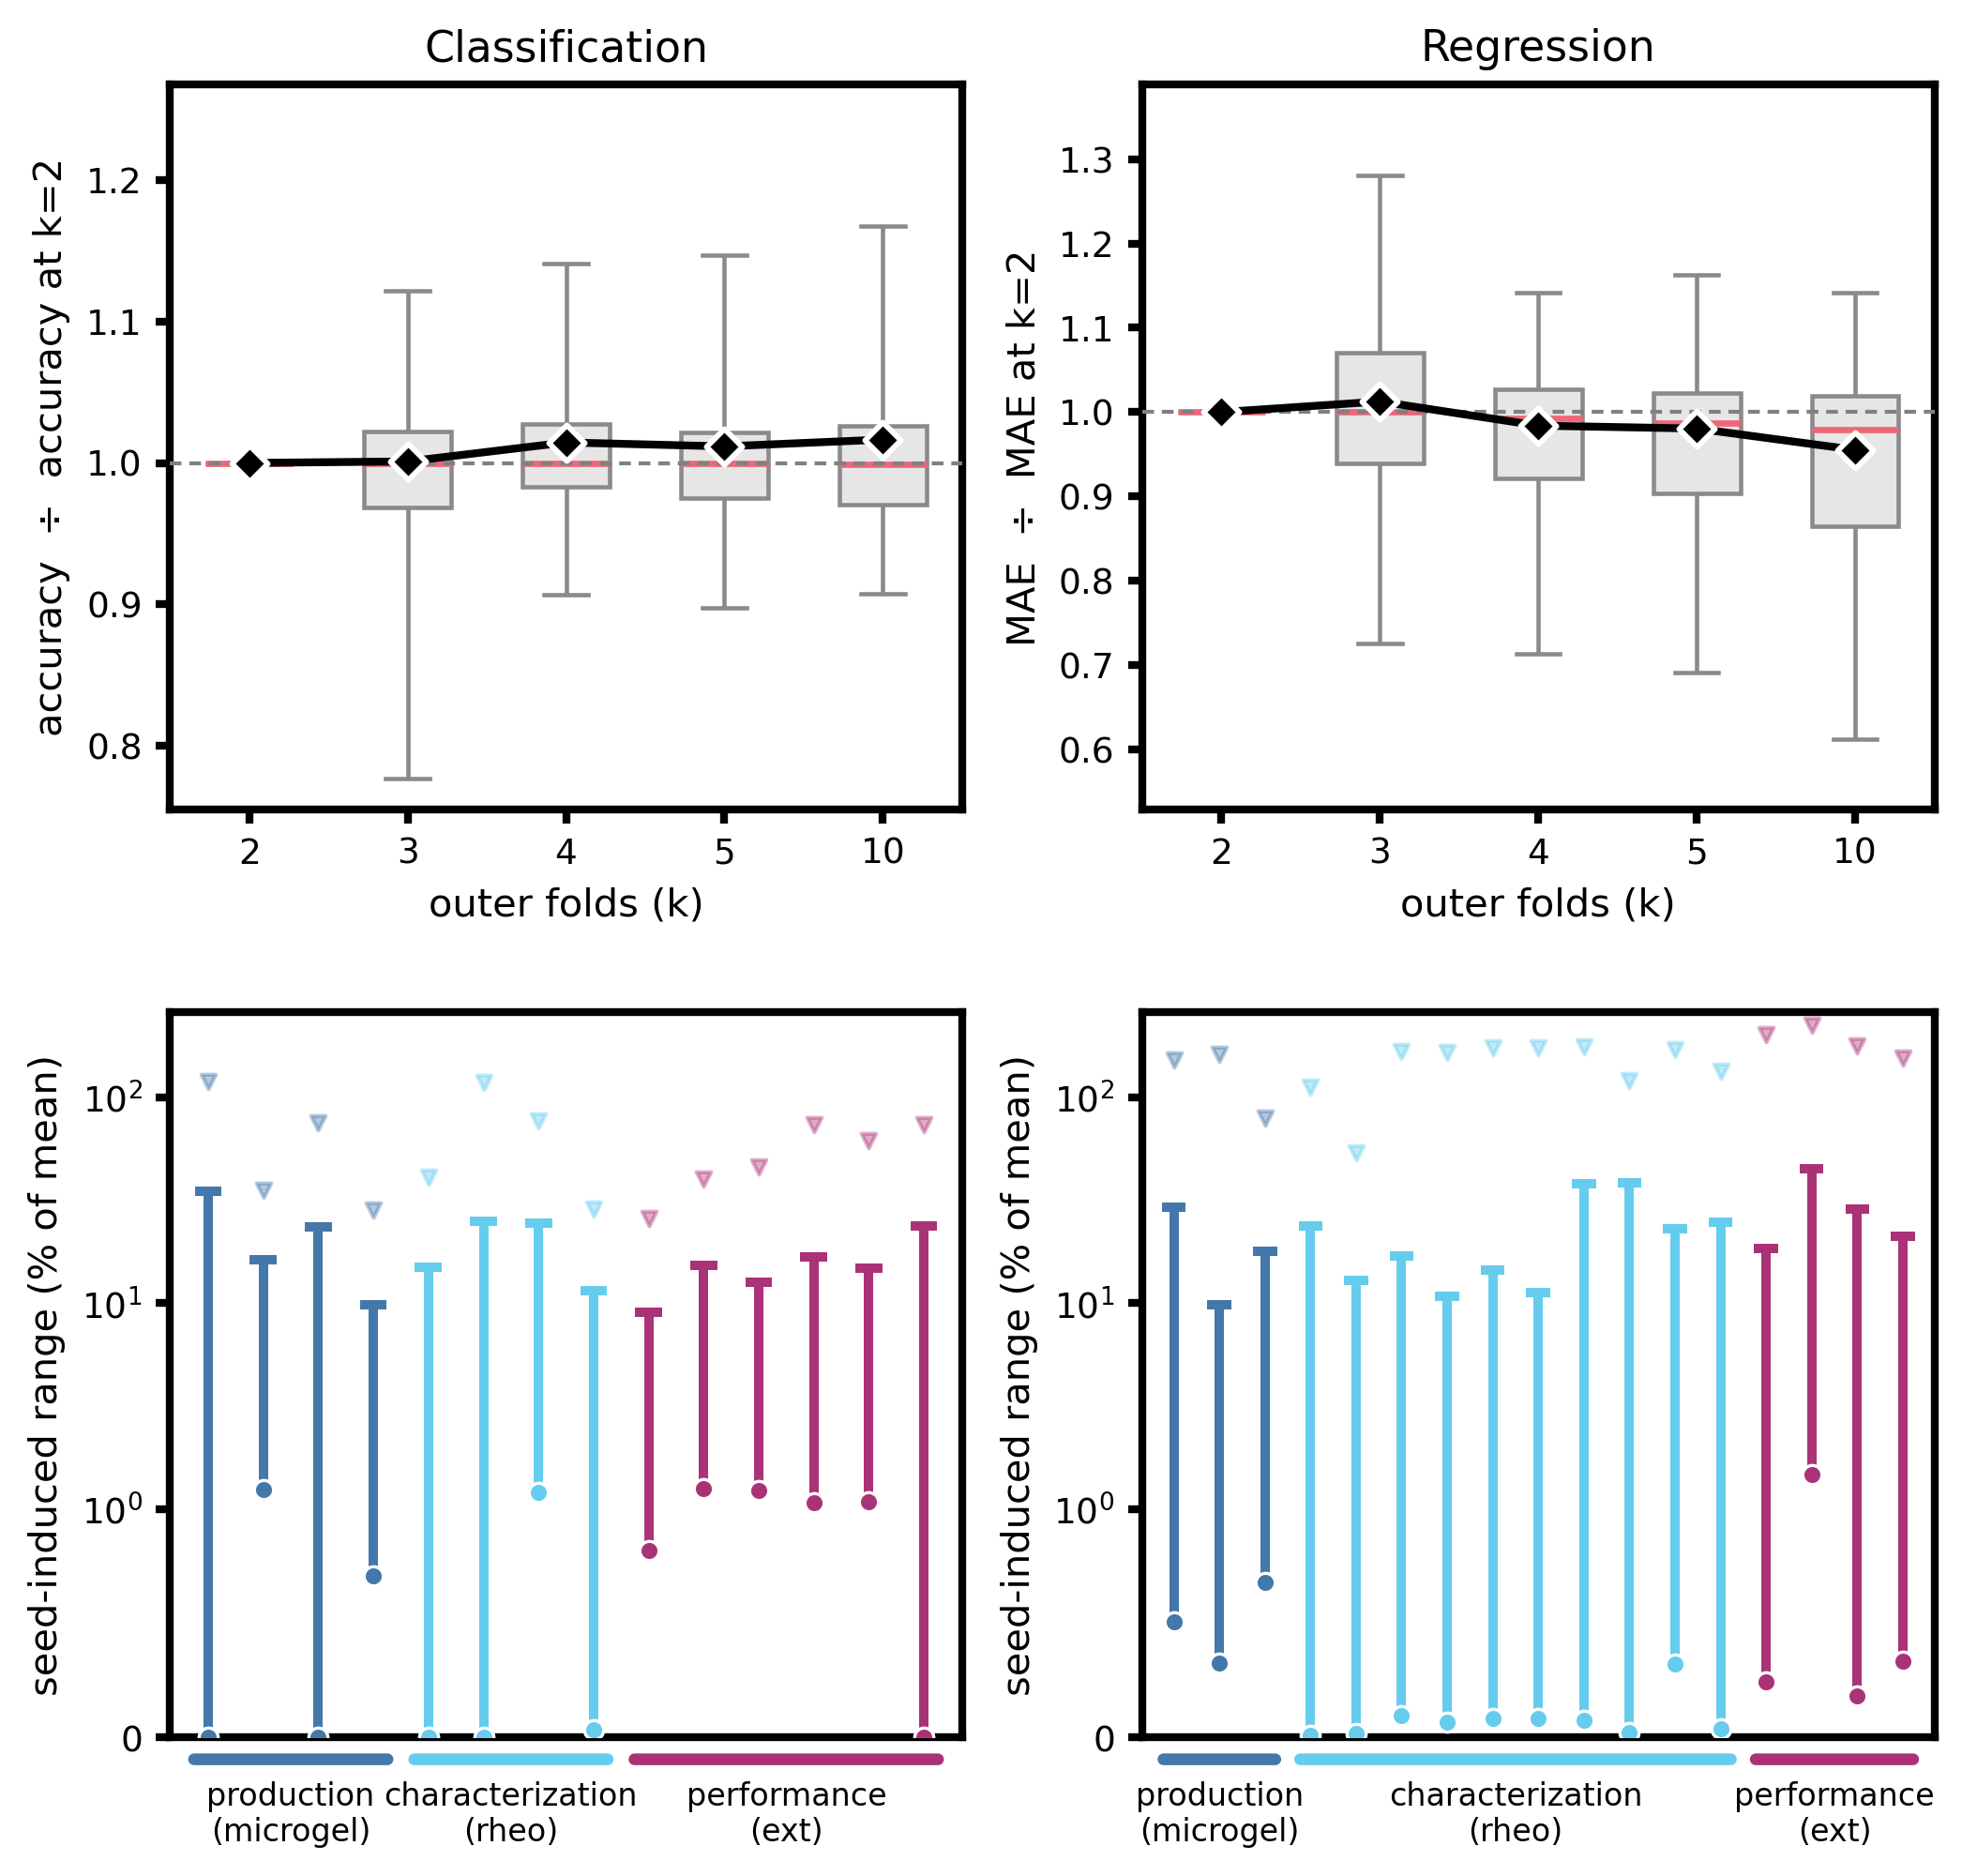

In [2]:
# ============================ F3 — analysis + figure ============================
import seaborn as sns          # header imports pd/np/plt; seaborn is only used here

# ---- domains, palette, ordering, small helpers ----
def domain_of(t):
    if t.startswith('microgel'): return 'production'
    if t.startswith('rheo'):     return 'characterization'
    if t.startswith('ext'):      return 'performance'
    return 'other'
DOMAIN = {t: domain_of(t) for t in file_names}
domain_palette = {'production':'#4477AA', 'characterization':'#66CCEE',
                  'performance':'#AA3377', 'other':'#999999'}
DOMAIN_ORDER = {'production':0, 'characterization':1, 'performance':2, 'other':3}
dsort = lambda ts: sorted(ts, key=lambda x: (DOMAIN_ORDER[DOMAIN[x]], x))
def robust_ylim(vals, lo=2, hi=98, pad=0.08):
    a, b = np.nanpercentile(vals, [lo, hi]); r = (b - a) * pad or 1e-6
    return a - r, b + r
plt.rcParams.update({
    'axes.linewidth': 2.0, 'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'xtick.major.width': 2.0, 'ytick.major.width': 2.0, 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

# ---- pooled-test frames (shared F2/F3 foundation) ----
def pooled_test(tasks):
    return pd.concat([out_agg[t][out_agg[t].fold == 'test'].assign(task=t, domain=DOMAIN[t])
                      for t in tasks], ignore_index=True)
df_clf, df_reg = pooled_test(clf), pooled_test(reg)

# ---- derived frames: k-ratio (each instance / its own k=2) and seed dispersion ----
K_REF = 2
M1 = {'clf': 'mean_accuracy', 'reg': 'mean_MAE'}
def k_ratio(df, ycol):
    base = (df[df.outer_k == K_REF]
              .set_index(['task', 'combo_id', 'iteration'])[ycol].rename('base').to_frame())
    d = df.join(base, on=['task', 'combo_id', 'iteration'])
    d = d.assign(ratio=d[ycol] / d['base'])
    return d.replace([np.inf, -np.inf], np.nan).dropna(subset=['ratio'])
def seed_disp(df, ycol):
    g = (df.groupby(['task', 'domain', 'algorithm', 'combo_id', 'outer_k'])[ycol]
           .agg(['min', 'max', 'mean']).reset_index())
    g['seed_rel_range'] = (g['max'] - g['min']) / g['mean'].abs() * 100.0
    return g.replace([np.inf, -np.inf], np.nan).dropna(subset=['seed_rel_range'])
k_clf,  k_reg  = k_ratio(df_clf, M1['clf']),  k_ratio(df_reg, M1['reg'])
sd_clf, sd_reg = seed_disp(df_clf, M1['clf']), seed_disp(df_reg, M1['reg'])

# ================================ figure ================================
fig, axes = plt.subplots(2, 2, figsize=(180/25.4, 180/25.4))
(axK_c, axK_r), (axS_c, axS_r) = axes

# --- row 1: k -> box (p5-p95 whiskers) + MEAN trend; red line = median ---
# convention: clf up = better; reg MAE down = better (not inverted)
KORD = [2, 3, 4, 5, 10]
def k_panel(ax, f, ylabel):
    sns.boxplot(data=f, x='outer_k', y='ratio', order=KORD, ax=ax, whis=(5, 95),
                showfliers=False, color='0.9', linewidth=1.1, width=0.55,
                medianprops=dict(color='#EE6677', lw=1.6))
    mean = f.groupby('outer_k')['ratio'].mean().reindex(KORD)
    ax.plot(range(len(KORD)), mean.values, color='black', lw=2.0, zorder=9)
    ax.scatter(range(len(KORD)), mean.values, marker='D', s=42, color='black',
               edgecolor='white', linewidth=1.4, zorder=10)
    ax.axhline(1.0, color='0.5', lw=1.0, ls=(0, (3, 2)), zorder=3)
    ax.set_xlabel('outer folds (k)'); ax.set_ylabel(ylabel)
    ax.set_ylim(*robust_ylim(f['ratio']))
k_panel(axK_c, k_clf, 'accuracy  ÷  accuracy at k=2')
k_panel(axK_r, k_reg, 'MAE  ÷  MAE at k=2')
axK_c.set_title('Classification'); axK_r.set_title('Regression')

# --- row 2: seed -> per-task tail glyph (median dot, line to p95, v at max) + domain brackets ---
BR_LBL = {'production':'production\n(microgel)', 'characterization':'characterization\n(rheo)',
          'performance':'performance\n(ext)'}
def domain_brackets(ax, order):
    doms = [DOMAIN[t] for t in order]
    for d in ['production', 'characterization', 'performance']:
        idxs = [i for i, dd in enumerate(doms) if dd == d]
        if not idxs: continue
        c = (min(idxs) + max(idxs)) / 2; col = domain_palette[d]
        ax.annotate('', xy=(min(idxs)-0.4, -0.03), xytext=(max(idxs)+0.4, -0.03),
                    xycoords=('data', 'axes fraction'),
                    arrowprops=dict(arrowstyle='-', lw=3.0, color=col), annotation_clip=False)
        ax.annotate(BR_LBL[d], xy=(c, -0.06), xycoords=('data', 'axes fraction'),
                    ha='center', va='top', fontsize=8, color='black', annotation_clip=False)
def tail_stats(f, tasks):
    g = f.groupby('task')['seed_rel_range']
    return {t: (g.get_group(t).median(), np.nanpercentile(g.get_group(t), 95),
                g.get_group(t).max()) for t in tasks}
def seed_panel(ax, f, tasks, ylabel):
    order = dsort(tasks); st = tail_stats(f, order)
    for i, t in enumerate(order):
        c = domain_palette[DOMAIN[t]]; m, hi, mx = st[t]
        ax.vlines(i, m, hi, color=c, lw=2.4, zorder=5)
        ax.plot([i-0.16, i+0.16], [hi, hi], color=c, lw=2.4, zorder=5)
        ax.scatter(i, mx, marker='v', s=14, color=c, alpha=0.4, zorder=4)
        ax.scatter(i, m, marker='o', s=24, color=c, edgecolor='white', lw=0.8, zorder=6)
    ax.set_yscale('symlog', linthresh=1); ax.set_ylim(0, 260)
    ax.set_xlim(-0.7, len(order)-0.3)
    ax.set_xticks(range(len(order))); ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0); ax.set_xlabel(''); ax.set_ylabel(ylabel)
    domain_brackets(ax, order)
seed_panel(axS_c, sd_clf, clf, 'seed-induced range (% of mean)')
seed_panel(axS_r, sd_reg, reg, 'seed-induced range (% of mean)')

fig.tight_layout(rect=(0, 0.05, 1, 1), h_pad=2.5)

In [3]:
from pathlib import Path
figdir = REPO / "figures"; figdir.mkdir(exist_ok=True)
fig.savefig(figdir / "Figure3_nonmodeling.pdf", dpi=300, bbox_inches='tight')
fig.savefig(figdir / "Figure3_nonmodeling.png", dpi=300, bbox_inches='tight')  # for quick viewing
print("saved to", figdir)

saved to C:\Users\conno\Documents\GitHub\ML_MetaLearning_SoftMatter\figures


In [4]:
# VERIFY: seed % reflects real sensitivity, not a near-zero-denominator (ratio-explosion) artifact
for name, sd, df, yc in [('reg', sd_reg, df_reg, 'mean_MAE'), ('clf', sd_clf, df_clf, 'mean_accuracy')]:
    denom = sd['mean'].abs()
    tmed = df.groupby('task')[yc].median()
    big = sd[sd.seed_rel_range > 50].copy()
    big['task_scale'] = big['task'].map(tmed)
    tiny = big[big['mean'].abs() < 0.05 * big['task_scale'].abs()]   # denom < 5% of task-typical metric
    print(f"\n=== {name} ===")
    print(f"  denominator (per-instance seed-mean): min={denom.min():.4g}  p1={np.nanpercentile(denom,1):.4g}  median={denom.median():.4g}")
    print(f"  instances with range>50%: {len(big)} / {len(sd)}   |   of those, denom<5% of task-median: {len(tiny)}  (<- potential artifacts)")
    print("  largest-range rows (abs min/max/mean vs %):")
    print(big.nlargest(6, 'seed_rel_range')[['task','algorithm','outer_k','min','max','mean','seed_rel_range']].round(4).to_string(index=False))


=== reg ===
  denominator (per-instance seed-mean): min=0.05173  p1=0.06738  median=62.77
  instances with range>50%: 741 / 26813   |   of those, denom<5% of task-median: 0  (<- potential artifacts)
  largest-range rows (abs min/max/mean vs %):
            task algorithm  outer_k    min      max    mean  seed_rel_range
ext_quant_curves        LR       10 5.7633 101.0966 42.4558        224.5474
ext_quant_curves        LR        2 1.3707  67.1744 29.5402        222.7600
ext_quant_curves        LR        5 8.6036  88.5196 37.4125        213.6077
ext_quant_curves        LR        3 6.9166 100.1889 43.8879        212.5241
ext_quant_curves        LR        5 9.4835 100.5268 43.0604        211.4317
ext_quant_curves        LR        5 8.9481  81.6191 34.6872        209.5036

=== clf ===
  denominator (per-instance seed-mean): min=0.07547  p1=0.4347  median=0.8105
  instances with range>50%: 106 / 26320   |   of those, denom<5% of task-median: 0  (<- potential artifacts)
  largest-range rows (